# Setup

In [2]:
import pathlib
import torch
import numpy as np
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

import utils
import data

In [3]:
def load_experiment(exp_type, base_dir, exp_name, checkpoints = False):
    exp_path = pathlib.Path(base_dir) / exp_name
    if exp_type == "cca":
        experiment = utils.load_pca_cca(exp_path)
    elif exp_type == "coupler":
        experiment = utils.load_coupler_folds(exp_path, get_checkpoints = checkpoints)
    elif exp_type == "autoencoder":
        experiment = utils.load_jit_folds(exp_path, get_checkpoints = checkpoints)
    else:
        raise ValueError(f'Experiment type "{exp_type}" not recognized.')
    return experiment

def reg_loss(means, covs, latent_dim):
    mean_squared = torch.einsum("ni,ni->n", means, means)
    trace = torch.einsum("nii->n", covs)
    (det_sign, log_det) = torch.linalg.slogdet(covs)
    reg = 0.5*(mean_squared + trace - det_sign*log_det - latent_dim)
    return reg.mean()

class GaussianModel(torch.nn.Module):
    def __init__(self, encoder, decoder, latent_dim, input_data):
        super().__init__()
        self.chol = torch.nn.Parameter(torch.ones(input_data["logcpm"].shape[0], latent_dim, latent_dim))
        self.means = encoder(input_data)[0].detach()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, num_samples = 1, indices = None):
        samples = self.sample(num_samples, indices)
        flat_recon = self.decoder(samples.flatten(0, 1))
        reconstructions = {form: tensor.unflatten(0, samples.shape[:2]) for (form, tensor) in flat_recon.items()}
        return reconstructions

    def get_gaussian(self, indices = None):
        means = self.means if indices is None else self.means[indices]
        elements = self.chol if indices is None else self.chol[indices]
        diagonal = torch.nn.functional.softplus(torch.diagonal(elements, 0, -2, -1))
        chol = torch.diag_embed(diagonal) / 40 + torch.tril(elements, -1) / 100
        cov = torch.einsum("nij,nkj->nik", chol, chol)
        return (means, cov)

    def sample(self, num_samples, indices = None):
        means = self.means if indices is None else self.means[indices]
        elements = self.chol if indices is None else self.chol[indices]
        expanded_mean = means[:, None].expand(-1, num_samples, -1)
        diagonal = torch.nn.functional.softplus(torch.diagonal(elements, 0, -2, -1))
        chol = torch.diag_embed(diagonal)/ 40 + torch.tril(elements, -1) / 100
        noise = torch.einsum("nij,nsj->nsi", chol, torch.randn_like(expanded_mean))
        samples = expanded_mean + noise
        return samples

class PointEstimator(torch.nn.Module):
    def __init__(self, encoder, decoder, latent_dim, input_data):
        super().__init__()
        self.means = torch.nn.Parameter(encoder(input_data)[0])
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, indices = None):
        means = self.means if indices is None else self.means[indices]
        reconstructions = self.decoder(means)
        return reconstructions

In [5]:
dataset_folders = {
  "logcpm": "../data/transcriptomics",
  "pca-ipfx": "../data/electrophysiology",
  "arbors": "../data/morphology/densities/120_8_4/histogram"}
met = data.MET_Data("../data/meta/specimens.csv", **dataset_folders)
forms = {"T": "logcpm", "E": "pca-ipfx", "M": "arbors"}

# Model

In [11]:
exp_dict = load_experiment("autoencoder", "../data_old/rebalanced_full_fixed", "met_2d_100")
fold_dict = exp_dict["folds"][2]
(encoder, decoder) = (fold_dict["best"].model_dict["T"]["enc"], fold_dict["best"].model_dict["T"]["dec"])
spec_ids = met.query(fold_dict["train_ids"], formats = [("logcpm", "pca-ipfx", "arbors")], outputs = ["specimen_id"])
test_data = met.get_specimens(spec_ids["specimen_id"])
input_tensor = torch.from_numpy(test_data["logcpm"]).float()

In [379]:
model = GaussianModel(encoder, decoder, 2, {"logcpm": input_tensor})

In [382]:
optim = torch.optim.Adam([model.chol], lr = 1e-3)
steps = 100000
num_samples = 1
mse_frac = 1.0
try:
    for step in range(steps):
        optim.zero_grad()
        output = model(num_samples)["logcpm"]
        (mean, cov) = model.get_gaussian()
        mse = torch.square(input_tensor[:, None] - output).mean()
        loss = mse_frac*mse + (1 - mse_frac)*reg_loss(mean, cov, 2)
        loss.backward()
        optim.step()
        print(f"Step {step+1}: {loss:.4g}         ", end = "\r")
except KeyboardInterrupt:
    pass

In [348]:
1.874

1.874

In [383]:
(mean_tensor, cov_tensor) = model.get_gaussian()
(means, covs) = (mean_tensor.numpy(force = True), cov_tensor.numpy(force = True))
(eig_vals, eig_vecs) = np.linalg.eigh(covs)
rotation = 180*np.arccos(eig_vecs[:, 1, 0])/np.pi

# Gradient

In [388]:
out_func = lambda z: decoder(z)["logcpm"].detach()
n = 50 + 1
delta = 0.1
points = torch.linspace(-2.5, 2.5, n)
z_grid = torch.stack(torch.meshgrid(points, points), -1)
displ = torch.asarray([[delta, 0], [0, delta], [delta/2**0.5, delta/2**0.5], [delta/2**0.5, -delta/2**0.5]])
(plus, minus) = (z_grid[:, :, None] + displ[None, None], z_grid[:, :, None] - displ[None, None])
(plus_f, minus_f) = (plus.reshape(4*n**2, 2), minus.reshape(4*n**2, 2))
(output_plus, output_minus) = (out_func(plus_f.float()), out_func(minus_f.float()))
grad = (output_plus - output_minus) / (2*delta)
combined = abs(grad).reshape(n, n, 4, -1).sum(-1)
(max_val, max_dir) = torch.max(combined, -1)
(max_dir, max_val) = (max_dir.reshape(n, n), max_val.reshape(n, n))
max_val = max_val / max_val.max()

## Plots

### 1.0 Reg - 0.0 MSE

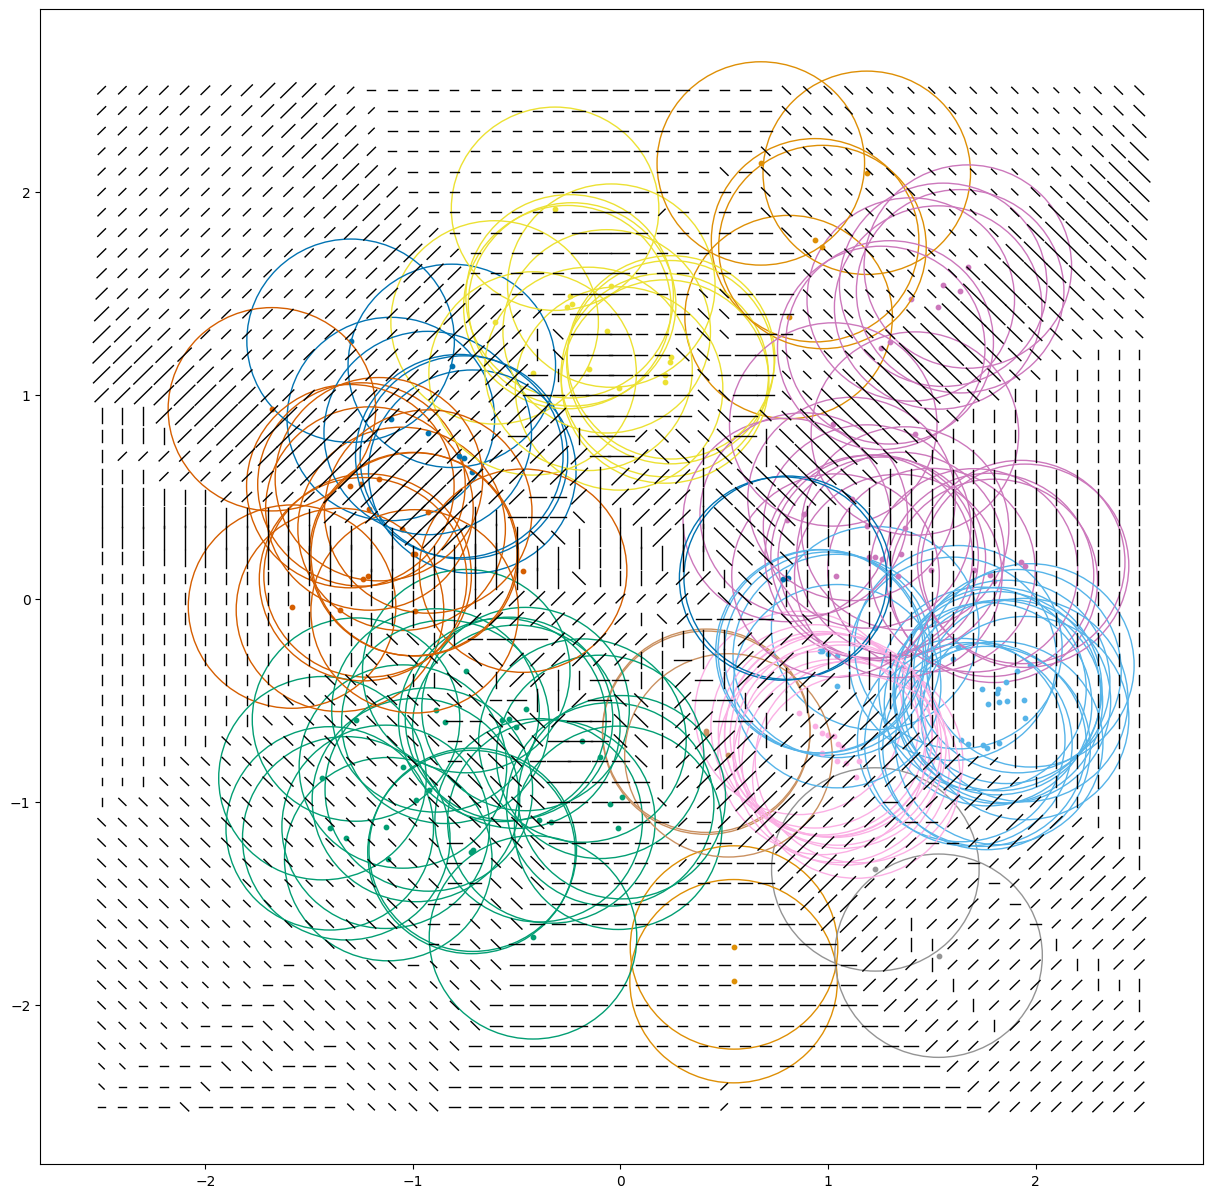

### 0.25 Reg - 0.75 MSE

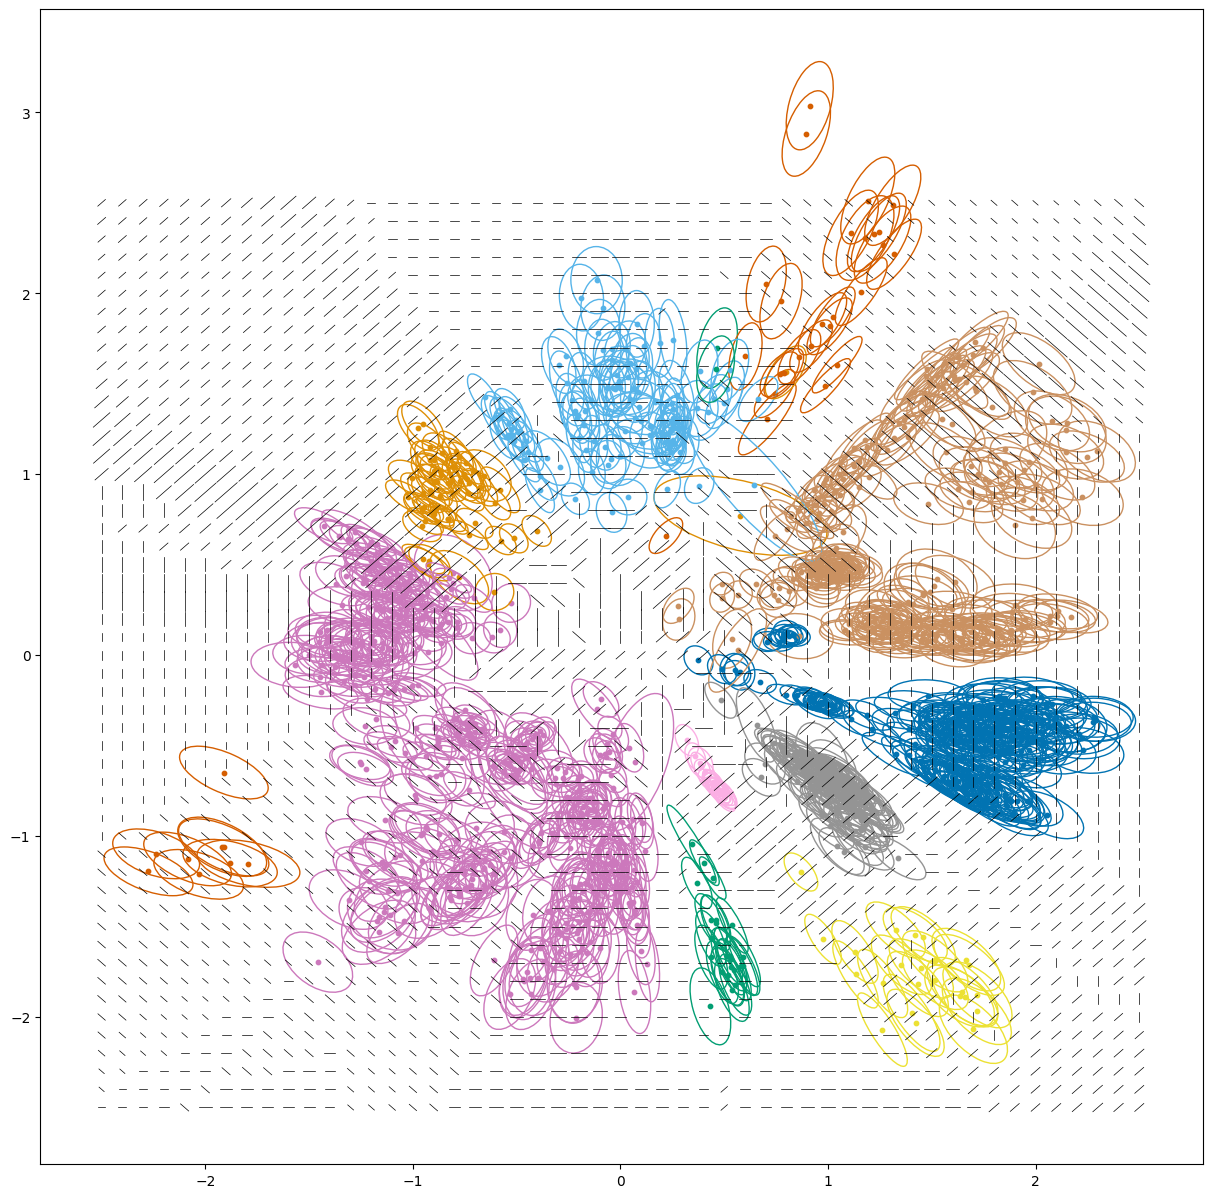

In [225]:
color_indices = np.unique(test_data["merged_cluster_label_at80"], return_inverse = True)[1]
colors = sns.color_palette("colorblind", np.max(color_indices) + 1)
(fig, ax) = plt.subplots(1, 1, figsize = (15, 15))
for ((x, y), (min_eig, max_eig), angle, color_index) in zip(means, eig_vals, rotation, color_indices):
    color = colors[color_index]
    ellipse = Ellipse(xy = (x, y), width = max_eig**0.5, height = min_eig**0.5, angle = angle, edgecolor = color, fc = 'None', lw = 1)
    ax.add_patch(ellipse)
    ax.scatter([x], [y], s = 10, color = color)
    

lines = displ
for (coords, row_dirs, row_vals) in zip(z_grid, max_dir, max_val):
    for (yx, dir, val) in zip(coords, row_dirs, row_vals):
        ((py_1, px_1), (py_2, px_2)) = (yx + lines[dir]*val, yx - lines[dir]*val)
        ax.plot([px_1, px_2], [py_1, py_2], color = "black", linewidth = 0.5)
plt.show()

### 0.0 Reg - 1.0 MSE

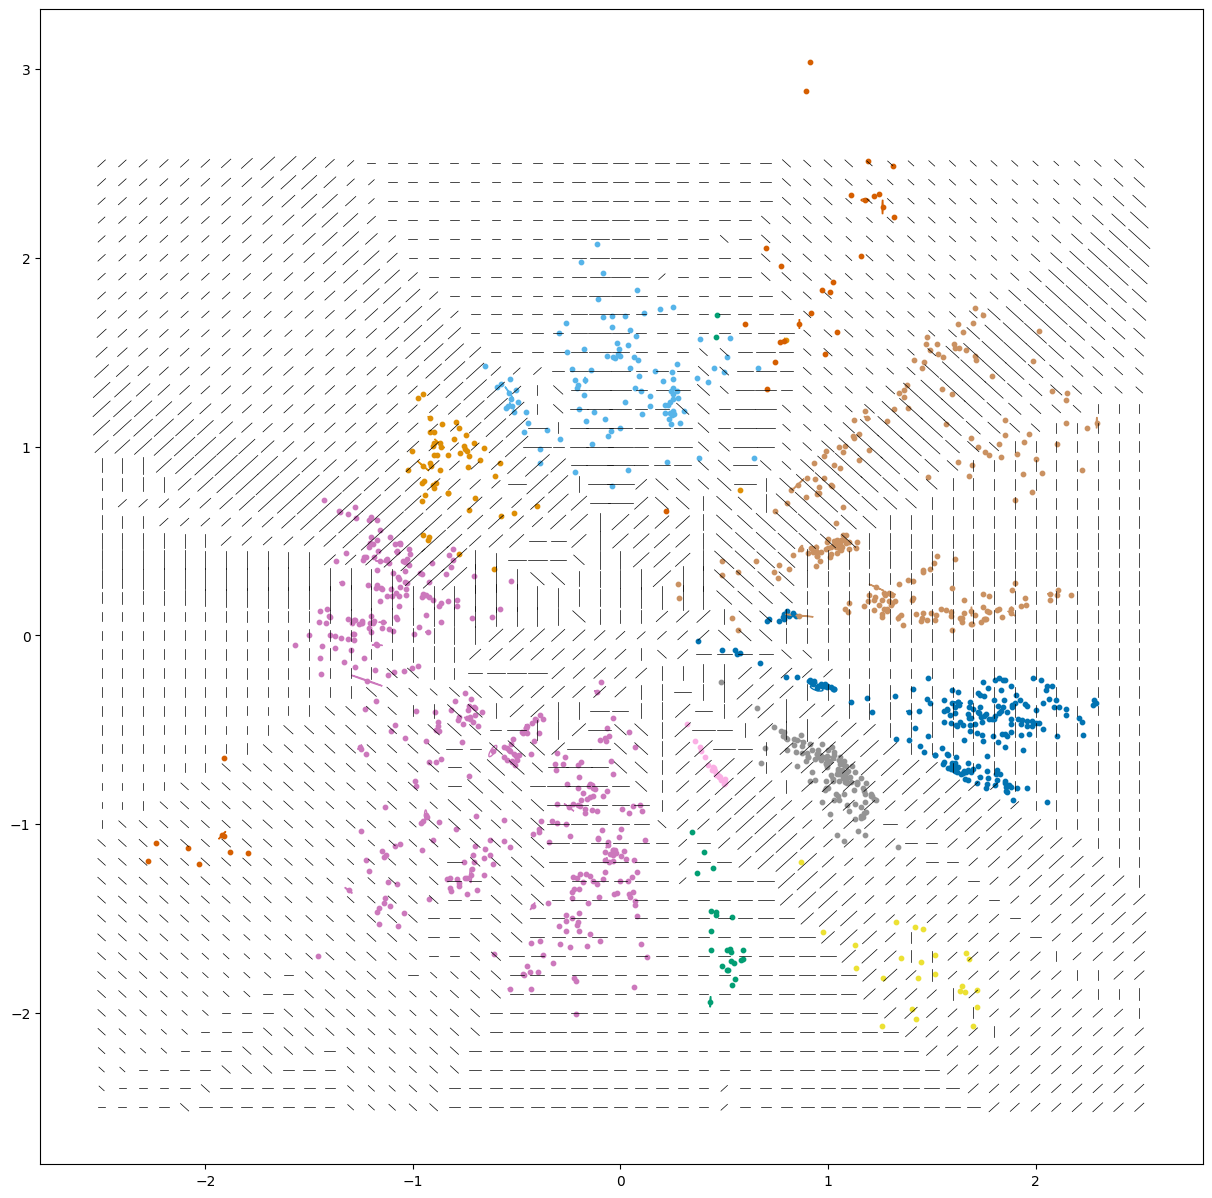

In [384]:
color_indices = np.unique(test_data["merged_cluster_label_at80"], return_inverse = True)[1]
colors = sns.color_palette("colorblind", np.max(color_indices) + 1)
(fig, ax) = plt.subplots(1, 1, figsize = (15, 15))
for ((x, y), (min_eig, max_eig), angle, color_index) in zip(means, eig_vals, rotation, color_indices):
    color = colors[color_index]
    ellipse = Ellipse(xy = (x, y), width = max_eig**0.5, height = min_eig**0.5, angle = angle, edgecolor = color, fc = 'None', lw = 1)
    ax.add_patch(ellipse)
    ax.scatter([x], [y], s = 10, color = color)
    

lines = displ
for (coords, row_dirs, row_vals) in zip(z_grid, max_dir, max_val):
    for (yx, dir, val) in zip(coords, row_dirs, row_vals):
        ((py_1, px_1), (py_2, px_2)) = (yx + lines[dir]*val, yx - lines[dir]*val)
        ax.plot([px_1, px_2], [py_1, py_2], color = "black", linewidth = 0.5)
plt.show()

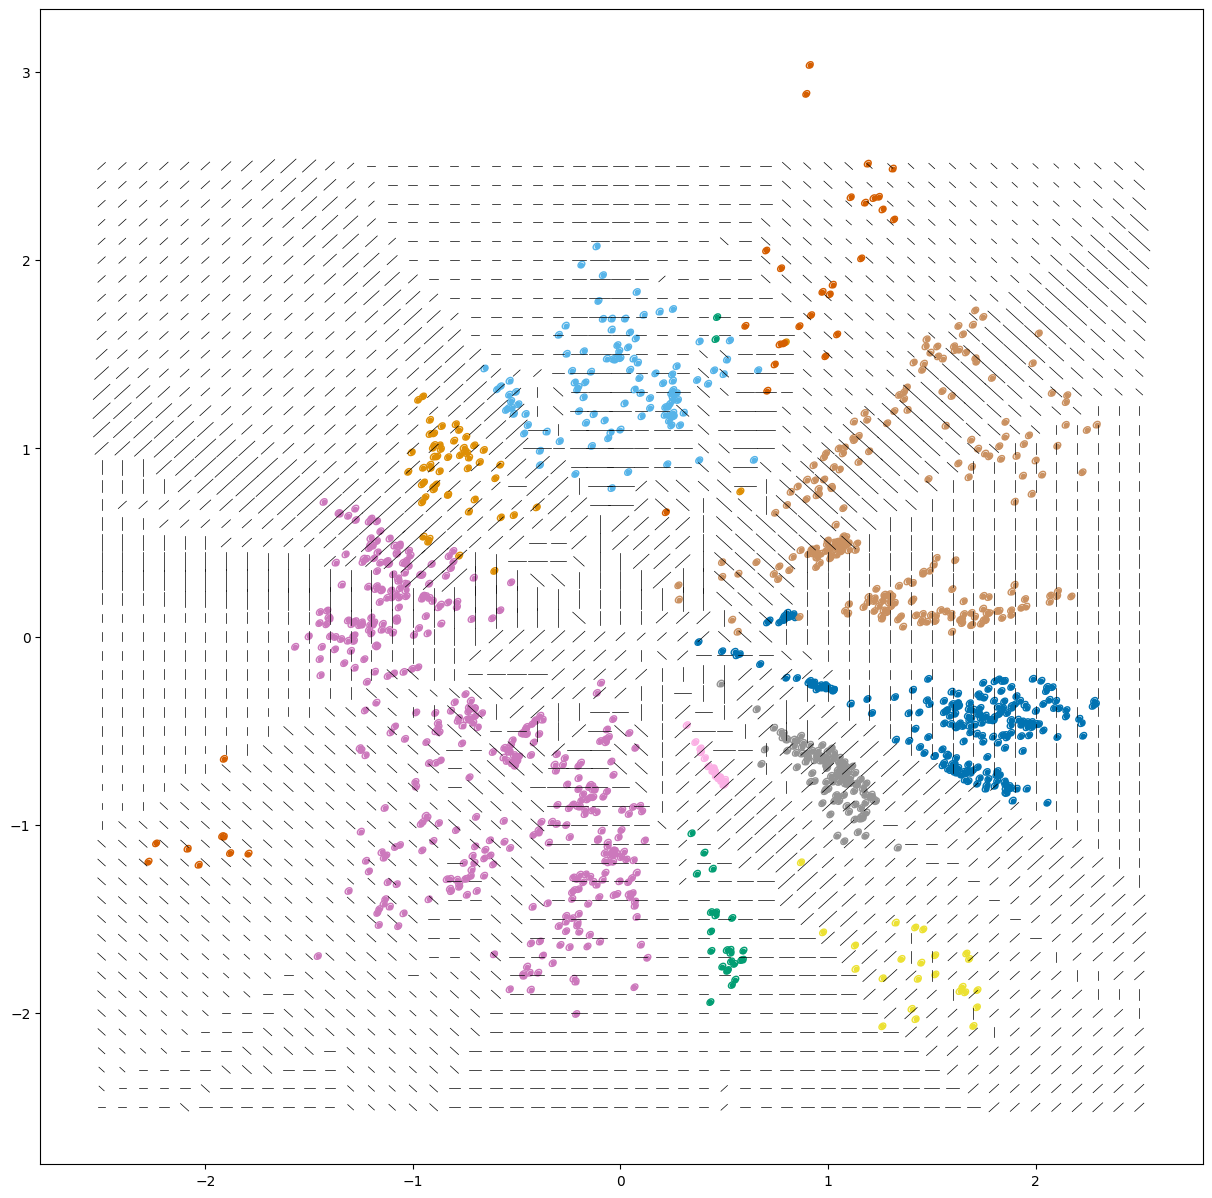

In [381]:
color_indices = np.unique(test_data["merged_cluster_label_at80"], return_inverse = True)[1]
colors = sns.color_palette("colorblind", np.max(color_indices) + 1)
(fig, ax) = plt.subplots(1, 1, figsize = (15, 15))
for ((x, y), (min_eig, max_eig), angle, color_index) in zip(means, eig_vals, rotation, color_indices):
    color = colors[color_index]
    ellipse = Ellipse(xy = (x, y), width = max_eig**0.5, height = min_eig**0.5, angle = angle, edgecolor = color, fc = 'None', lw = 1)
    ax.add_patch(ellipse)
    ax.scatter([x], [y], s = 10, color = color)
    

lines = displ
for (coords, row_dirs, row_vals) in zip(z_grid, max_dir, max_val):
    for (yx, dir, val) in zip(coords, row_dirs, row_vals):
        ((py_1, px_1), (py_2, px_2)) = (yx + lines[dir]*val, yx - lines[dir]*val)
        ax.plot([px_1, px_2], [py_1, py_2], color = "black", linewidth = 0.5)
plt.show()

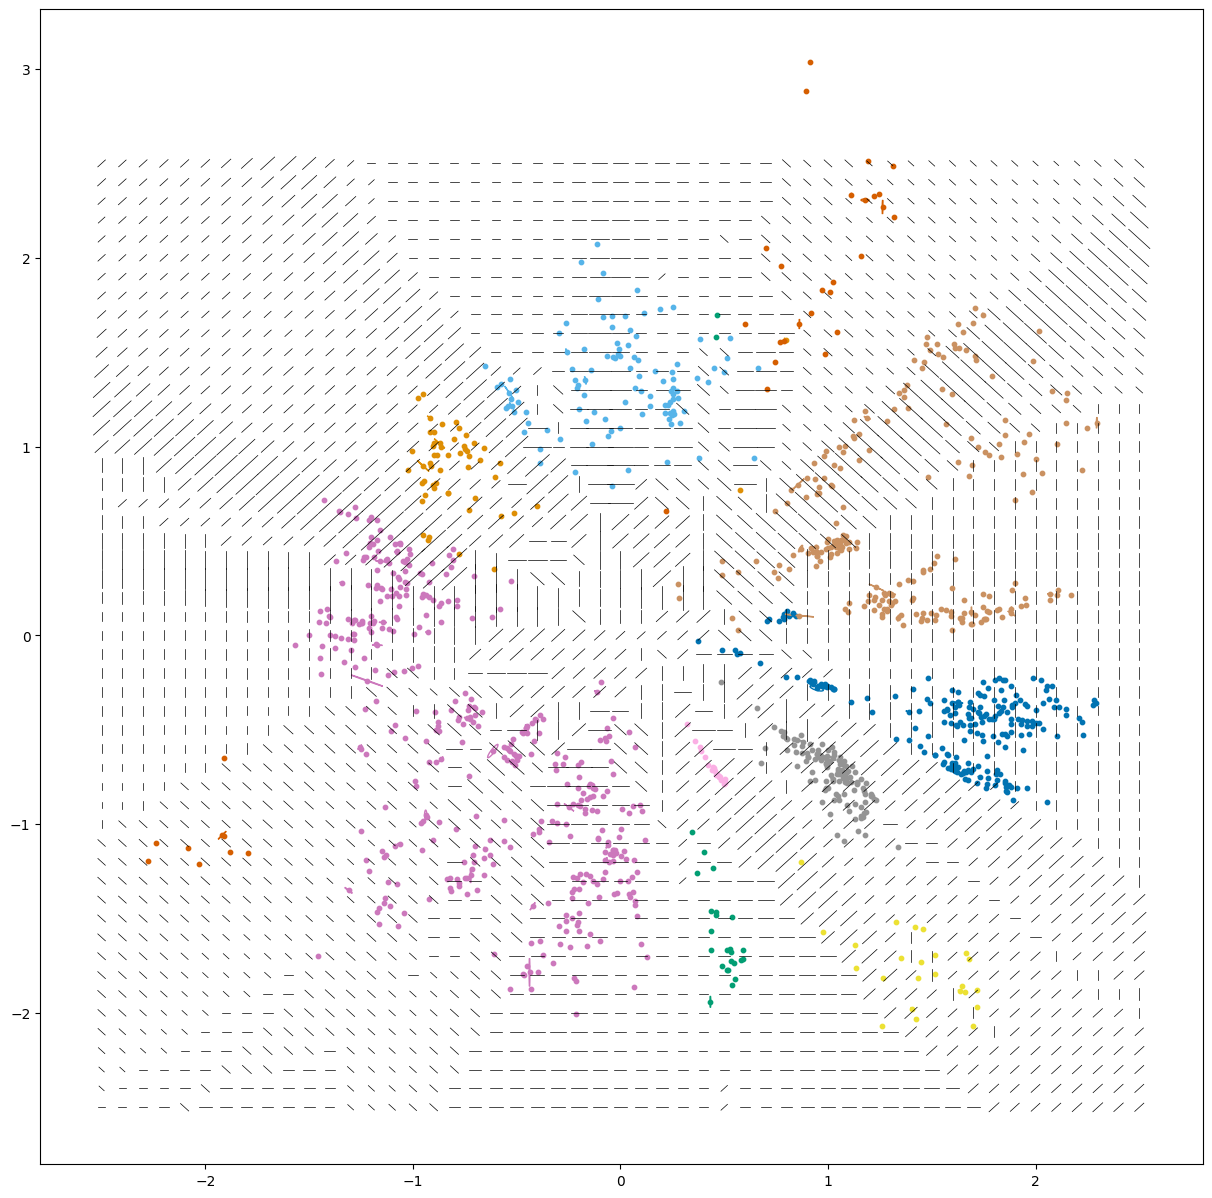

In [360]:
color_indices = np.unique(test_data["merged_cluster_label_at80"], return_inverse = True)[1]
colors = sns.color_palette("colorblind", np.max(color_indices) + 1)
(fig, ax) = plt.subplots(1, 1, figsize = (15, 15))
for ((x, y), (min_eig, max_eig), angle, color_index) in zip(means, eig_vals, rotation, color_indices):
    color = colors[color_index]
    ellipse = Ellipse(xy = (x, y), width = max_eig**0.5, height = min_eig**0.5, angle = angle, edgecolor = color, fc = 'None', lw = 1)
    ax.add_patch(ellipse)
    ax.scatter([x], [y], s = 10, color = color)
    

lines = displ
for (coords, row_dirs, row_vals) in zip(z_grid, max_dir, max_val):
    for (yx, dir, val) in zip(coords, row_dirs, row_vals):
        ((py_1, px_1), (py_2, px_2)) = (yx + lines[dir]*val, yx - lines[dir]*val)
        ax.plot([px_1, px_2], [py_1, py_2], color = "black", linewidth = 0.5)
plt.show()

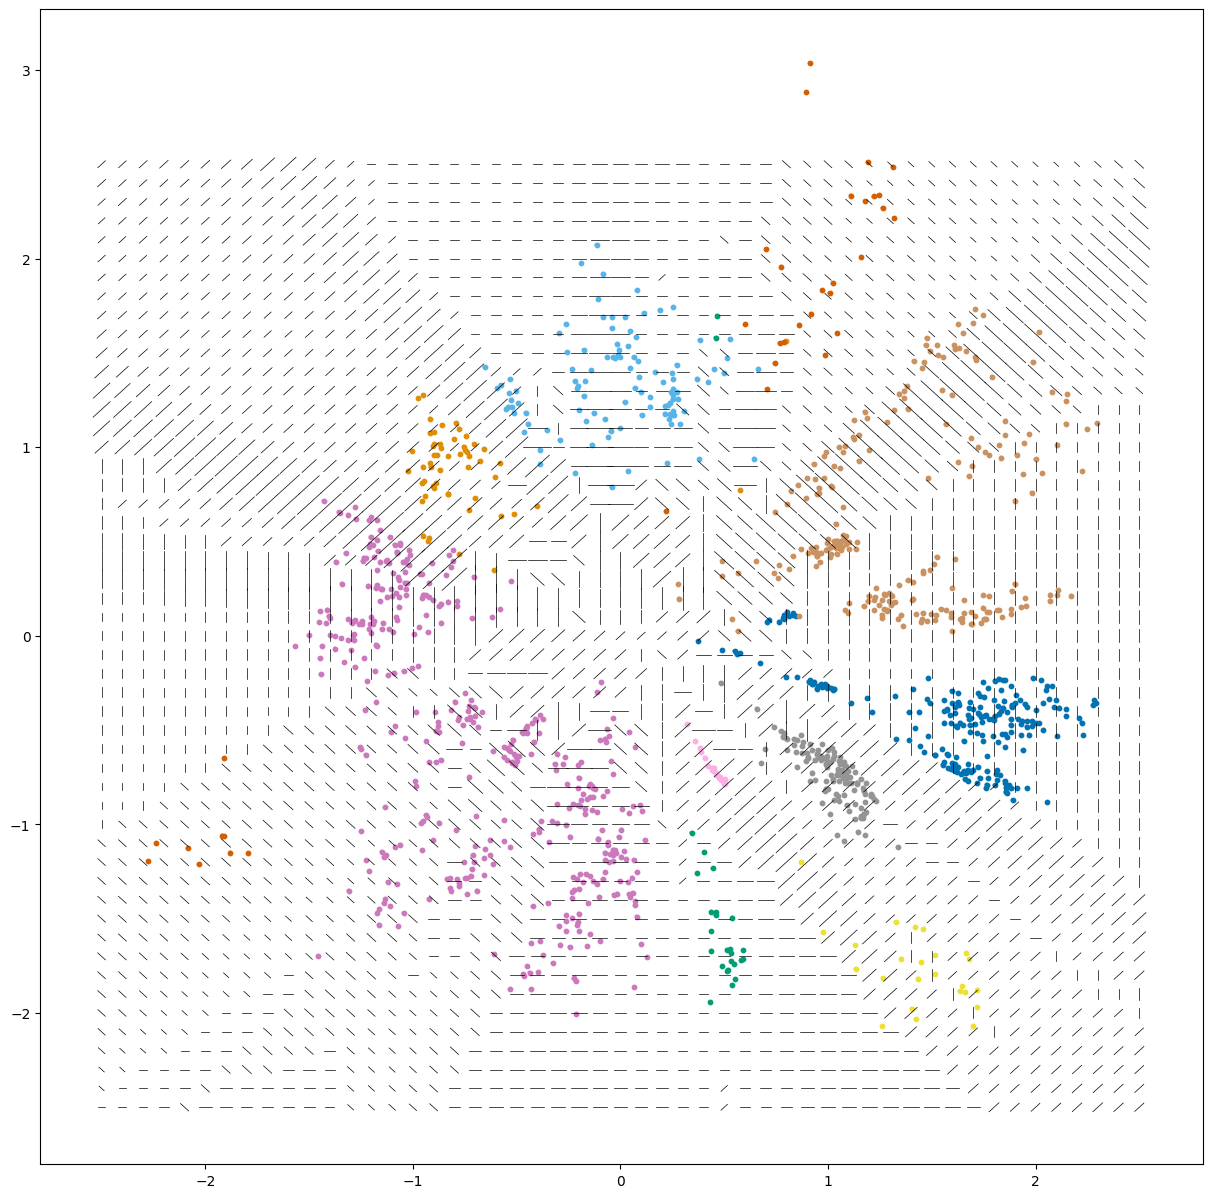

In [343]:
color_indices = np.unique(test_data["merged_cluster_label_at80"], return_inverse = True)[1]
colors = sns.color_palette("colorblind", np.max(color_indices) + 1)
(fig, ax) = plt.subplots(1, 1, figsize = (15, 15))
for ((x, y), (min_eig, max_eig), angle, color_index) in zip(means, eig_vals, rotation, color_indices):
    color = colors[color_index]
    ellipse = Ellipse(xy = (x, y), width = max_eig**0.5, height = min_eig**0.5, angle = angle, edgecolor = color, fc = 'None', lw = 1)
    ax.add_patch(ellipse)
    ax.scatter([x], [y], s = 10, color = color)
    

lines = displ
for (coords, row_dirs, row_vals) in zip(z_grid, max_dir, max_val):
    for (yx, dir, val) in zip(coords, row_dirs, row_vals):
        ((py_1, px_1), (py_2, px_2)) = (yx + lines[dir]*val, yx - lines[dir]*val)
        ax.plot([px_1, px_2], [py_1, py_2], color = "black", linewidth = 0.5)
plt.show()

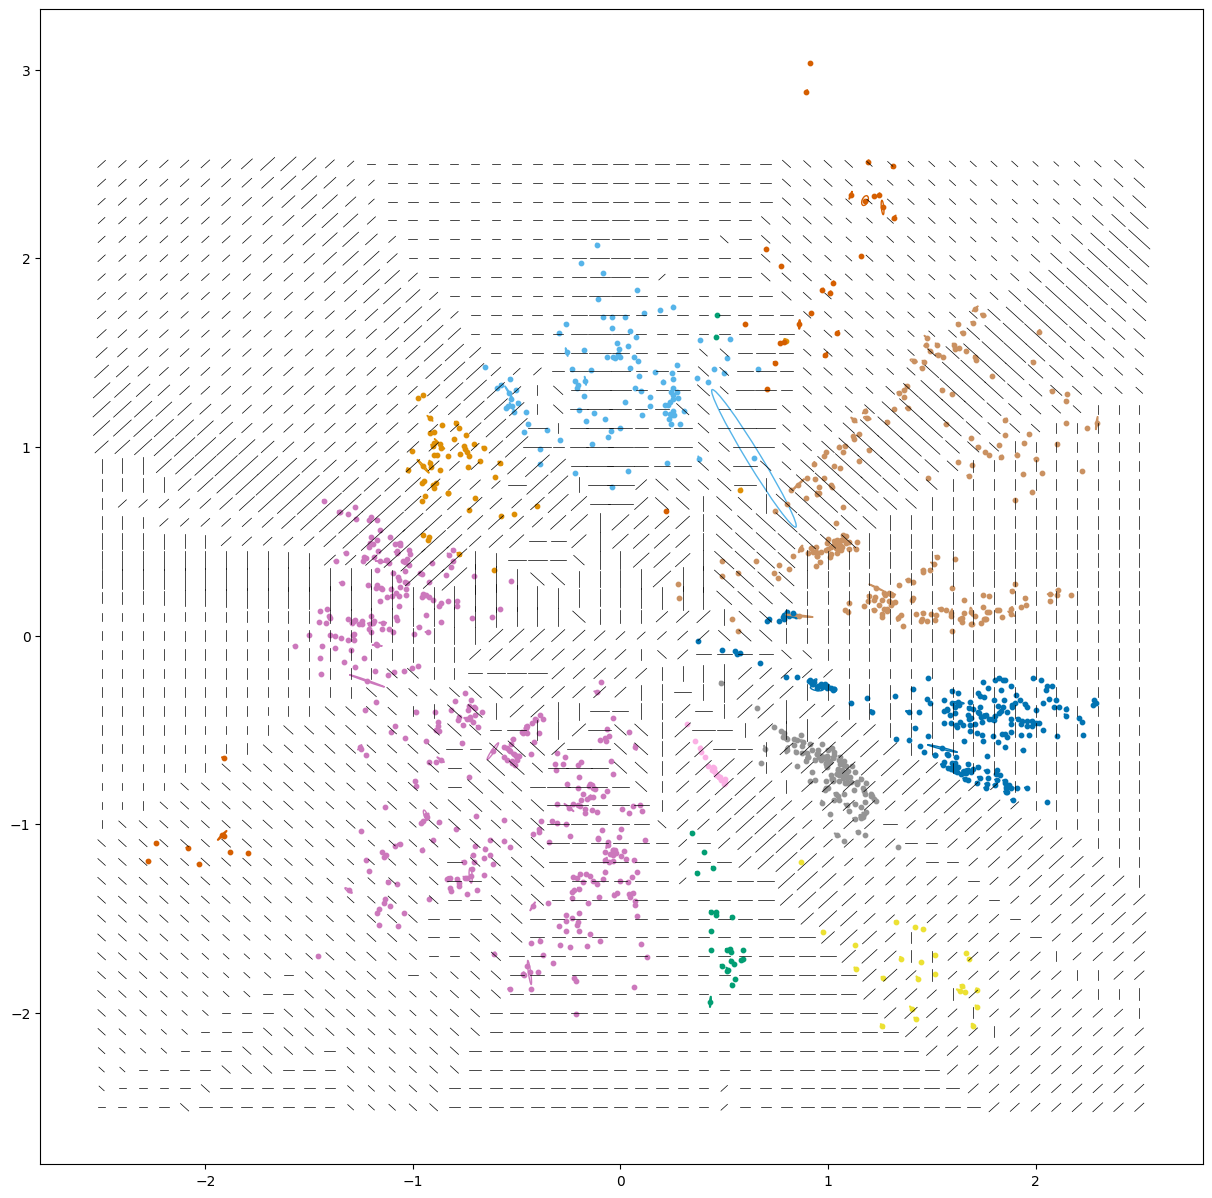

In [230]:
color_indices = np.unique(test_data["merged_cluster_label_at80"], return_inverse = True)[1]
colors = sns.color_palette("colorblind", np.max(color_indices) + 1)
(fig, ax) = plt.subplots(1, 1, figsize = (15, 15))
for ((x, y), (min_eig, max_eig), angle, color_index) in zip(means, eig_vals, rotation, color_indices):
    color = colors[color_index]
    ellipse = Ellipse(xy = (x, y), width = max_eig**0.5, height = min_eig**0.5, angle = angle, edgecolor = color, fc = 'None', lw = 1)
    ax.add_patch(ellipse)
    ax.scatter([x], [y], s = 10, color = color)
    

lines = displ
for (coords, row_dirs, row_vals) in zip(z_grid, max_dir, max_val):
    for (yx, dir, val) in zip(coords, row_dirs, row_vals):
        ((py_1, px_1), (py_2, px_2)) = (yx + lines[dir]*val, yx - lines[dir]*val)
        ax.plot([px_1, px_2], [py_1, py_2], color = "black", linewidth = 0.5)
plt.show()

### Other

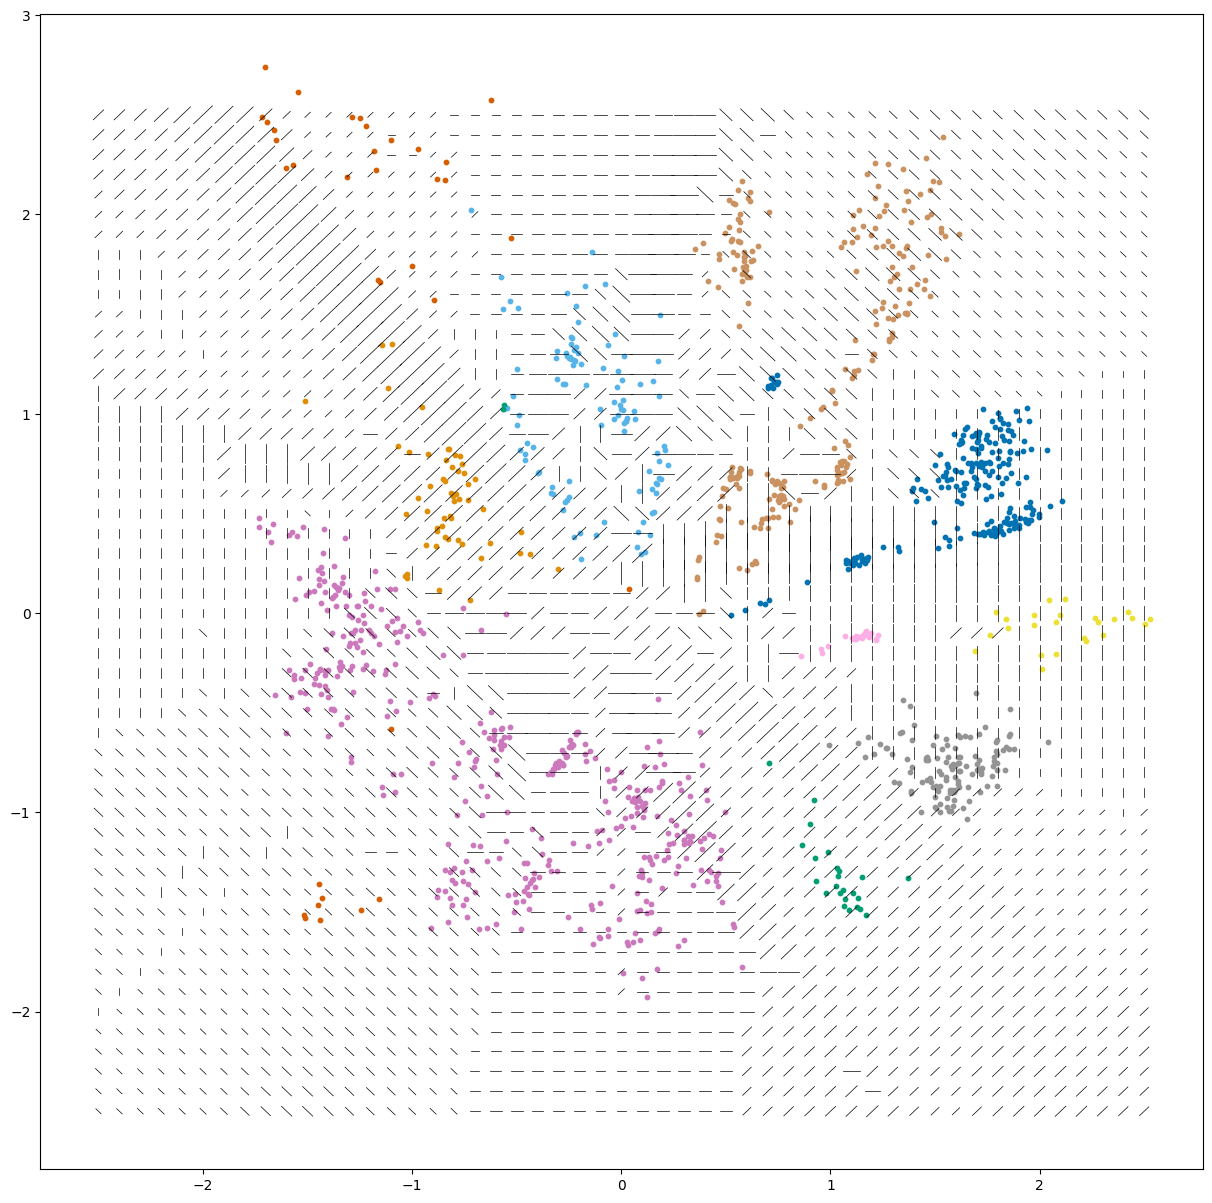

In [392]:
color_indices = np.unique(test_data["merged_cluster_label_at80"], return_inverse = True)[1]
colors = sns.color_palette("colorblind", np.max(color_indices) + 1)
(fig, ax) = plt.subplots(1, 1, figsize = (15, 15))
for ((x, y), (min_eig, max_eig), angle, color_index) in zip(means, eig_vals, rotation, color_indices):
    color = colors[color_index]
    ellipse = Ellipse(xy = (x, y), width = max_eig**0.5, height = min_eig**0.5, angle = angle, edgecolor = color, fc = 'None', lw = 1)
    ax.add_patch(ellipse)
    ax.scatter([x], [y], s = 10, color = color)
    

lines = displ
for (coords, row_dirs, row_vals) in zip(z_grid, max_dir, max_val):
    for (yx, dir, val) in zip(coords, row_dirs, row_vals):
        ((py_1, px_1), (py_2, px_2)) = (yx + lines[dir]*val, yx - lines[dir]*val)
        ax.plot([px_1, px_2], [py_1, py_2], color = "black", linewidth = 0.5)
plt.show()

# Point Estimates

In [231]:
estimator = PointEstimator(encoder, decoder, 2, {"logcpm": input_tensor})

In [232]:
optim = torch.optim.Adam([estimator.means], lr = 1e-3)
steps = 100000
try:
    for step in range(steps):
        optim.zero_grad()
        output = estimator()["logcpm"]
        loss = torch.square(input_tensor - output).mean()
        loss.backward()
        optim.step()
        print(f"Step {step+1}: {loss:.4g}         ", end = "\r")
except KeyboardInterrupt:
    pass
means_0 = estimator.means.numpy(force = True)

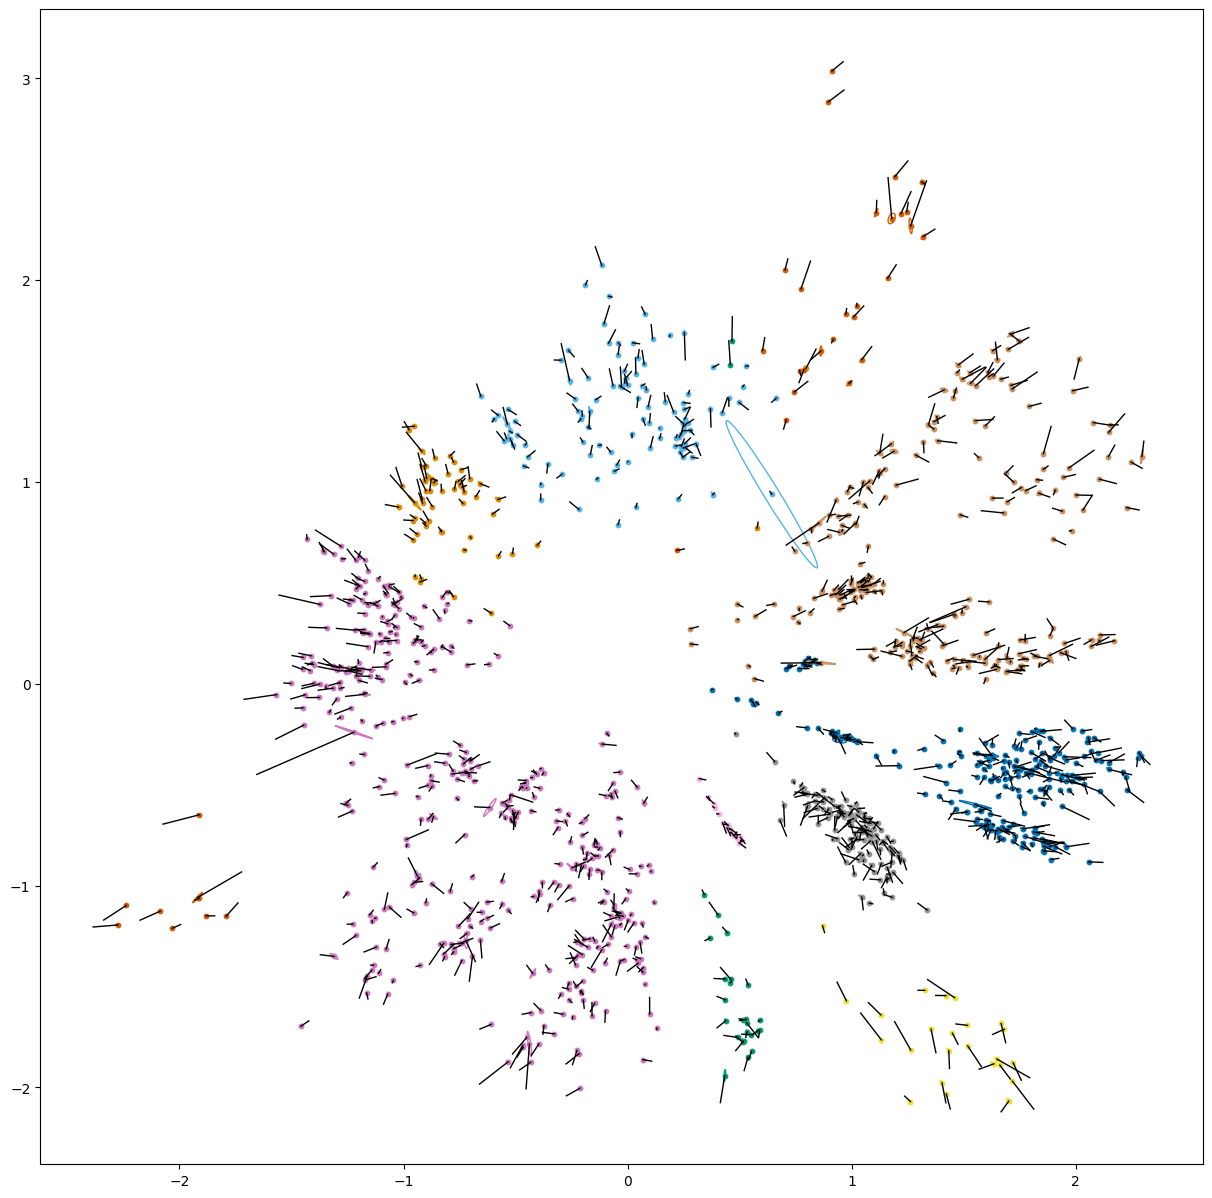

In [233]:
color_indices = np.unique(test_data["merged_cluster_label_at80"], return_inverse = True)[1]
colors = sns.color_palette("colorblind", np.max(color_indices) + 1)
(fig, ax) = plt.subplots(1, 1, figsize = (15, 15))
for ((x, y), (x_0, y_0), (min_eig, max_eig), angle, color_index) in zip(means, means_0, eig_vals, rotation, color_indices):
    color = colors[color_index]
    ellipse = Ellipse(xy = (x, y), width = max_eig**0.5, height = min_eig**0.5, angle = angle, edgecolor = color, fc = 'None', lw = 1)
    ax.add_patch(ellipse)
    ax.scatter([x], [y], s = 10, color = color)
    ax.plot([x, x_0], [y, y_0], color = "black", linewidth = 1)
plt.show()

# Axis Search

In [255]:
size_order = np.argsort(eig_vals[:, 1])[::-1]

### Major Axis

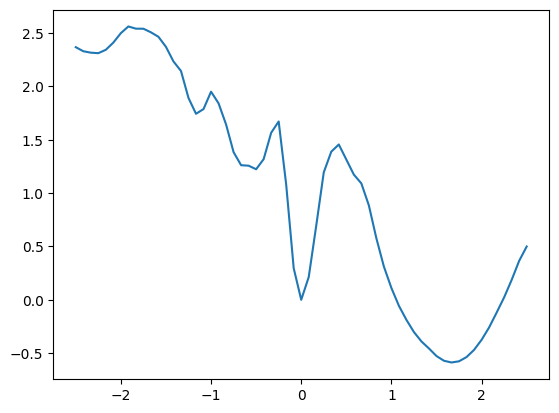

In [261]:
n = 61
spacing = np.linspace(-3, 3, n)
displacements = (eig_vals[:, 1:2, None]**0.5)*spacing[None, :, None]*eig_vecs[:, None, :, 1]
shifted_means = model.means[:, None] + displacements
recons = model.decoder(shifted_means.flatten(0, 1).float())["logcpm"].unflatten(0, shifted_means.shape[0:2]).numpy(force = True)
mse = np.square(test_data["logcpm"][:, None] - recons).mean(-1)
for (displ, errors) in zip(displacements[size_order], mse[size_order]):
    plt.plot(np.sign(spacing)*np.linalg.norm(displ, axis = 1), errors - errors[n // 2])
    plt.show()
    break

In [243]:
improvement = mse[:, n//2, None] - mse
best = np.max(improvement, axis = -1)

0.5873801982973479


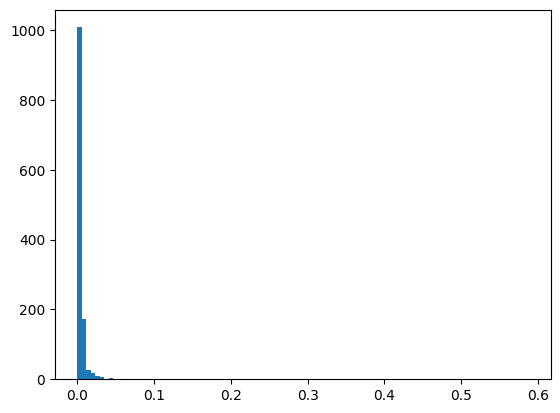

In [244]:
print(best.max())
plt.hist(best, 100)
plt.show()

### Minor Axis

In [245]:
n = 41
spacing = np.linspace(-2, 2, n)
displacements = (eig_vals[:, 1:2, None]**0.5)*spacing[None, :, None]*eig_vecs[:, None, :, 0]
shifted_means = model.means[:, None] + displacements
recons = model.decoder(shifted_means.flatten(0, 1).float())["logcpm"].unflatten(0, shifted_means.shape[0:2]).numpy(force = True)
mse = np.square(test_data["logcpm"][:, None] - recons).mean(-1)
improvement = mse[:, n//2, None] - mse
best = np.max(improvement, axis = -1)

0.0720888850803516


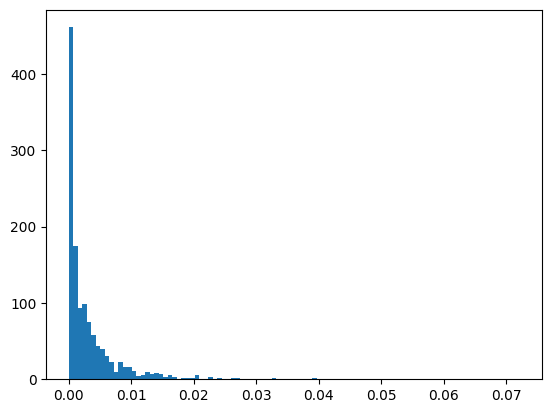

In [246]:
print(best.max())
plt.hist(best, 100)
plt.show()

### Random Direction

In [247]:
rand_vecs = np.random.normal(0, 1, eig_vecs.shape)
rand_vecs = rand_vecs / np.linalg.norm(rand_vecs, axis = 1, keepdims = True)
n = 41
spacing = np.linspace(-2, 2, n)
displacements = (eig_vals[:, 1:2, None]**0.5)*spacing[None, :, None]*rand_vecs[:, None, :, 0]
shifted_means = model.means[:, None] + displacements
recons = model.decoder(shifted_means.flatten(0, 1).float())["logcpm"].unflatten(0, shifted_means.shape[0:2]).numpy(force = True)
mse = np.square(test_data["logcpm"][:, None] - recons).mean(-1)
improvement = mse[:, n//2, None] - mse
best = np.max(improvement, axis = -1)

0.12147844070462943


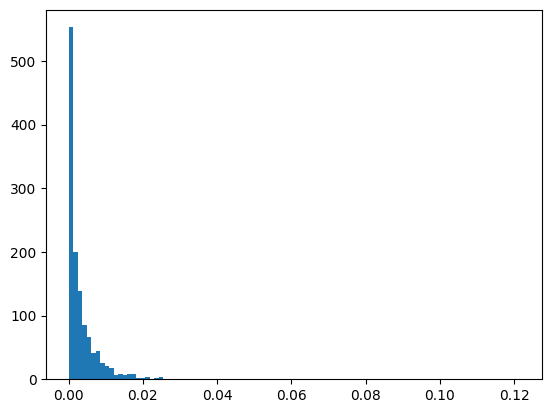

In [248]:
print(best.max())
plt.hist(best, 100)
plt.show()

# Loss Landscape

In [271]:
sample = model.means.numpy()[size_order][0]

In [299]:
bounds = 2
n = 201
points = np.stack(np.meshgrid(np.linspace(-bounds, bounds, n), np.linspace(-bounds, bounds, n)), -1)
z_points = points + sample[None, None]
recons = model.decoder(torch.from_numpy(z_points).flatten(0, 1).float())["logcpm"].unflatten(0, points.shape[:2]).numpy(force = True)
mse = np.square(test_data["logcpm"][size_order][0][None, None] - recons).mean(-1)

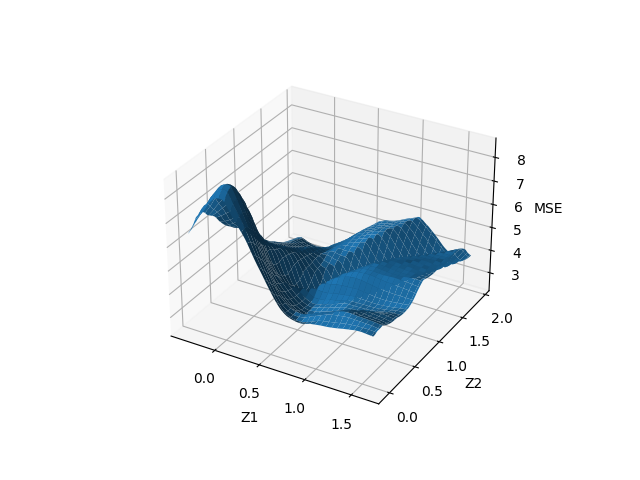

In [294]:
# %matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(111, projection = "3d")
ax.plot_surface(z_points[:, :, 0], z_points[:, :, 1], mse)
ax.set_xlabel("Z1")
ax.set_ylabel("Z2")
ax.set_zlabel("MSE")
plt.show()

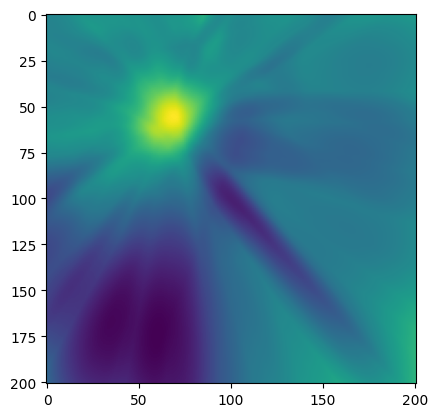

In [300]:
%matplotlib inline
plt.imshow(mse)
plt.show()